In [1]:
from IPython.core.pylabtools import figsize

#定义标签和中文名称的映射关系
classification_names={
    0:'上衣',
    1:'鞋',
    2:'包',
    3:'下装',
    4:'手表'
}

In [31]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
import torchvision.transforms as T
import numpy as np
import pandas as pd
import os
from torch.utils.data import Dataset, DataLoader, random_split
from common.utils import sorted_alphanum
import torch.nn as nn
from tqdm import tqdm

# 自定义数据集类

In [6]:
class ImageLabelDataset(Dataset):
    #初始化
    def __init__(self, image_dir, label_path, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_names = sorted_alphanum(os.listdir(image_dir))
        label_df = pd.read_csv(label_path)
        self.labels = label_df['target'].tolist()

    #获取数据集长度
    def __len__(self):
        return len(self.image_names)

    #根据索引号获取元素:(input,target)=(image,label)
    def __getitem__(self, idx):
        #1.构建图片的网站访问路径
        image_path = os.path.join(self.image_dir, self.image_names[idx])
        #2.打开图片
        image = Image.open(image_path).convert("RGB")
        #3.图像转换,(调整大小,转换Tensor)
        if self.transform is not None:
            img_tensor = self.transform(image)
        else:  #(抛出异常)
            raise ValueError("transform 参数不能为None!")
        #4.找到图片对应的标签
        img_label = self.labels[idx]

        return img_tensor, img_label

## 创建和划分数据集

In [7]:
#定义图片转换操作(调整大小,转为Tensor)
transform=T.Compose([#排版
    T.Resize((64,64)),
    T.ToTensor(),#直接归一化+float
])

dataset=ImageLabelDataset(image_dir='../common/dataset/',label_path='../common/fashion-labels.csv',transform=transform)
# print(dataset.image_names)
print(len(dataset))

24853


In [10]:
print(dataset[0][0].shape)

torch.Size([3, 64, 64])


In [12]:
#划分数据集
train_dataset,test_dataset=random_split(dataset,[0.8,0.2])
print(len(train_dataset))
print(len(test_dataset))

19883
4970


In [13]:
batch_size=32
#创建加载器
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size)

In [14]:
for input,target in train_loader:
    print(f"input shape:{input.shape},target shape:{target.shape}")
    break

input shape:torch.Size([32, 3, 64, 64]),target shape:torch.Size([32])


In [15]:
data_iter=iter(train_loader)
input,target=next(data_iter)
print(input.shape)
print(target.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


## 定义模型

In [24]:
class Classifier(nn.Module):
    #初始化,传入分类数
    def __init__(self,n_classes=5):
        super(Classifier,self).__init__()
        self.model=nn.Sequential(
            nn.Conv2d(3,8,3,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(8,16,3,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Flatten(),

            nn.Linear(16*16*16,n_classes)
        )

    #定义前向传播
    def forward(self,x):
        return self.model(x)


In [25]:
model=Classifier()
output=model(input)
print(output.shape)
print(output)

torch.Size([32, 5])
tensor([[-3.1860e-02, -1.2726e-04,  9.9290e-03, -1.1475e-02,  7.3278e-02],
        [-7.5332e-03,  6.8633e-02, -6.8862e-03, -1.7159e-03,  6.6439e-02],
        [ 7.5236e-04,  1.0333e-02, -1.6574e-02, -3.0643e-03,  6.5288e-02],
        [-5.2154e-02,  9.1668e-03, -5.4823e-03, -2.2294e-02,  8.0288e-02],
        [-1.7502e-02, -4.1315e-03, -5.3457e-03, -4.1012e-02,  7.1941e-02],
        [-6.0989e-03,  5.4926e-02, -6.9750e-04, -2.6076e-02,  7.2880e-02],
        [-3.2550e-02,  1.1296e-02, -3.8374e-02, -2.1109e-02,  8.6245e-02],
        [-6.0465e-02,  3.3234e-02,  1.4511e-02, -2.7219e-02,  4.3267e-02],
        [-2.8686e-02,  3.9141e-02,  9.0331e-03, -2.3272e-02,  9.9151e-02],
        [-4.9335e-02,  1.3150e-02, -7.0345e-03, -5.0110e-02,  1.1325e-01],
        [-3.5609e-02,  8.5007e-03,  3.2968e-03, -3.0469e-02,  6.0047e-02],
        [-1.8785e-02,  3.4758e-02, -3.4622e-03, -3.8358e-02,  6.3239e-02],
        [-4.0882e-02, -4.4345e-04, -1.0740e-02, -3.3104e-02,  1.1791e-01],
     

## 模型训练

In [26]:
#1.超参数
lr=1e-3
epochs=10

#sheb
device='cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

Classifier(
  (model): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=4096, out_features=5, bias=True)
  )
)

In [27]:
#2.损失函数(多分类专用)
loss_fn=nn.CrossEntropyLoss()

In [28]:
#优化器
optimizer=torch.optim.Adam(model.parameters(),lr=lr)

In [32]:
#训练流程
for epoch in tqdm(range(epochs)):
    model.train()
    total_loss=0
    for input,target in train_loader:
        input,target=input.to(device),target.to(device)
        output=model(input)
        loss=loss_fn(output,target)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss+=loss.item()*input.shape[0]

    #计算这一轮次平均损失
    train_loss=total_loss/len(train_dataset)
    print(f"Epoch :{epoch+1},Train Loss:{train_loss:.6f}")

 10%|█         | 1/10 [00:11<01:42, 11.36s/it]

Epoch :1,Train Loss:0.027289


 20%|██        | 2/10 [00:23<01:35, 11.94s/it]

Epoch :2,Train Loss:0.022362


 30%|███       | 3/10 [00:33<01:17, 11.01s/it]

...

Epoch :8,Train Loss:0.009515


 90%|█████████ | 9/10 [01:40<00:10, 10.90s/it]

Epoch :9,Train Loss:0.007832


100%|██████████| 10/10 [01:51<00:00, 11.15s/it]

Epoch :10,Train Loss:0.007214


In [49]:
print(loss)
print(loss.item())

tensor(0.0050, device='cuda:0', grad_fn=<NllLossBackward0>)
0.004975450225174427


## 测试

In [33]:
# 模拟输入新图片,进行预测
data_iter=iter(test_loader)

In [34]:
#1.获取测试数据和标签
images,labels=next(data_iter)

In [35]:
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


In [37]:
#2.前向传播
with torch.no_grad():
    inputs=images.to(device)
    outputs=model(inputs)
print(outputs.shape)

torch.Size([32, 5])


In [40]:
#3.得到预测分类标签
pred_labels=outputs.argmax(dim=-1).cpu().numpy()
print(pred_labels.shape)

(32,)


In [41]:
#4.画图
images=images.permute(0,2,3,1).numpy()
print(images.shape)

(32, 64, 64, 3)


1-label:3,分类:下装
1-pred_label:3,分类:下装

2-label:1,分类:鞋
2-pred_label:1,分类:鞋

3-label:0,分类:上衣
3-pred_label:0,分类:上衣

4-label:4,分类:手表
4-pred_label:4,分类:手表

5-label:0,分类:上衣
5-pred_label:0,分类:上衣

6-label:0,分类:上衣
6-pred_label:0,分类:上衣

7-label:4,分类:手表
7-pred_label:4,分类:手表

8-label:4,分类:手表
8-pred_label:4,分类:手表

9-label:0,分类:上衣
9-pred_label:0,分类:上衣

10-label:0,分类:上衣
10-pred_label:0,分类:上衣



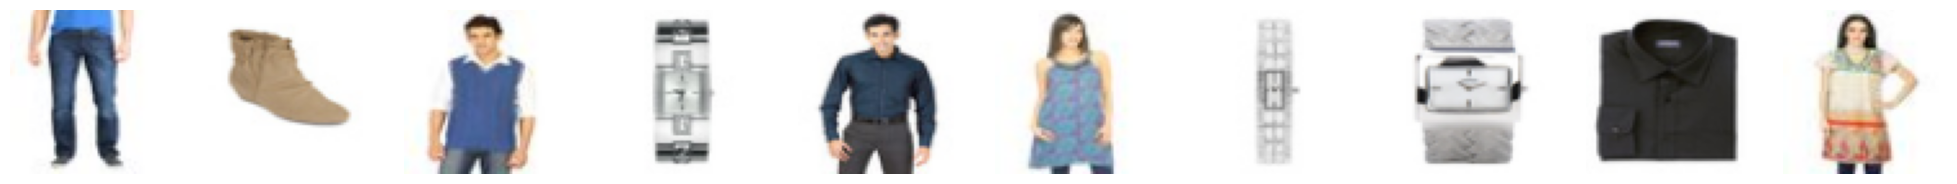

In [43]:
fig,axes=plt.subplots(1,10,figsize=(25,4),sharex=True,sharey=True)
for i in range(10):
    axes[i].imshow(images[i])
    axes[i].set_axis_off()
    #单独打印真实标签
    pred_class=classification_names[pred_labels[i]]
    print(f"{i+1}-label:{labels[i]},分类:{pred_class}")
    #预测标签
    print(f"{i+1}-pred_label:{pred_labels[i]},分类:{pred_class}")
    print()
plt.show()

In [45]:
#计算测试集准确率
test_acc_num=0
with torch.no_grad():
    # model.eval()
    for input,target in test_loader:
        input,target=input.to(device),target.to(device),
        outputs=model(input)
        #得到预测分类
        pred=outputs.argmax(dim=-1)
        #统计准确个数,累加
        test_acc_num+= pred.eq(target).sum().item()
test_acc=test_acc_num/len(test_dataset)

print(f"准确率:{test_acc:.6f}")


准确率:0.988934


In [48]:
print(pred.eq(target).sum())
print(pred.eq(target).sum().item())

tensor(10, device='cuda:0')
10
